In [2]:
# requirements:
!pip install pandas spacy stanza scikit-learn scipy matplotlib seaborn conllu langdetect

import pandas as pd
import re
import ast
from collections import Counter

# ── 1a. Load Hindi tweets corpus ──────────────────────────────────────────────
hindi_df = pd.read_csv("hindi.csv", encoding="utf-8")
hindi_df = hindi_df[["username", "text", "hashtags"]].dropna(subset=["text"])
hindi_df["corpus"] = "hindi"
print(f"Hindi tweets loaded: {len(hindi_df)}")

# ── 1b. Load English tweets (only Definitely English rows) ───────────────────
eng_df = pd.read_csv("all.tsv", sep="\t")
eng_df = eng_df[eng_df["Definitely English"] == 1][["Tweet ID", "Tweet"]].copy()
eng_df = eng_df.rename(columns={"Tweet": "text"}).dropna(subset=["text"])
eng_df["corpus"] = "english"
print(f"English tweets loaded: {len(eng_df)}")

# ── 1c. Load code-mixed data (token\tLANG format) ────────────────────────────
def parse_codemixed_file(filepath):
    """Parse tab-separated token/language-tag files into sentence-level records."""
    sentences, current_tokens, current_tags = [], [], []
    with open(filepath, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                if current_tokens:
                    sentences.append({
                        "tokens": current_tokens[:],
                        "lang_tags": current_tags[:],
                        "text": " ".join(current_tokens),
                        "corpus": "codemixed"
                    })
                    current_tokens, current_tags = [], []
            else:
                parts = line.split("\t")
                if len(parts) == 2:
                    current_tokens.append(parts[0])
                    current_tags.append(parts[1])
        if current_tokens:  # flush last sentence
            sentences.append({
                "tokens": current_tokens,
                "lang_tags": current_tags,
                "text": " ".join(current_tokens),
                "corpus": "codemixed"
            })
    return pd.DataFrame(sentences)

cm_df = parse_codemixed_file("test.txt")
print(f"Code-mixed sentences loaded: {len(cm_df)}")

# ── 1d. Corpus summary table ──────────────────────────────────────────────────
print("\n=== CORPUS SUMMARY ===")
for name, df in [("Hindi", hindi_df), ("English", eng_df), ("Code-mixed", cm_df)]:
    texts = df["text"].astype(str)
    tokens = texts.str.split().explode()
    print(f"{name:12s}: {len(df):5d} records | "
          f"{len(tokens):6d} tokens | "
          f"avg len={tokens.groupby(level=0).count().mean():.1f}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 15.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 12.7 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=cf0769c878af79348275991fcd98960fb97abb10165ce383a9daa06abad0ebde
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
Hindi tweets loaded: 10128
English tweets loaded: 5086
Code-mixed sentences loaded: 6420

=== CORPUS SUMMARY ===
Hindi       : 10128 records | 316247 tokens | avg len=31.2
English     :  5086 records |  55055 tokens | avg len=10.8
Code-mixed  :  6420 records | 1

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter, defaultdict
import re
import stanza
import spacy
from itertools import groupby

# ── assumes hindi_df, eng_df, cm_df already exist from previous steps ─────────

nlp_en = spacy.load("en_core_web_sm", disable=["ner", "textcat"])
nlp_hi = stanza.Pipeline("hi", processors="tokenize,pos", verbose=False)

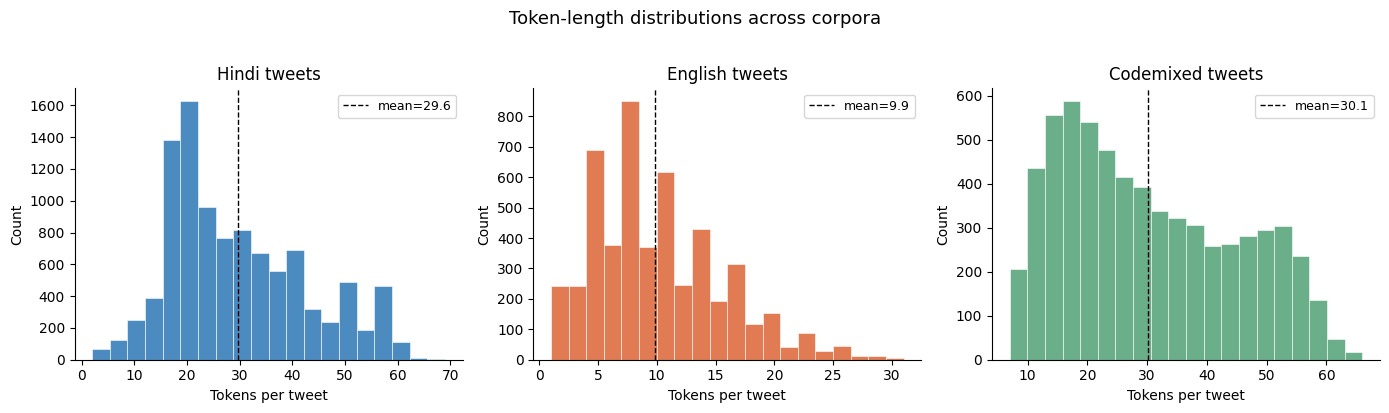

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# ── 2a. Basic text cleaning ───────────────────────────────────────────────────
URL_RE = re.compile(r"http\S+|www\S+")
MENTION_RE = re.compile(r"@\w+")
HASH_RE = re.compile(r"#(\w+)")
EMOJI_RE = re.compile("["
    u"\U0001F600-\U0001F64F"
    u"\U0001F300-\U0001F5FF"
    u"\U0001F680-\U0001F9FF"
    "]+", flags=re.UNICODE)

def clean_text(text: str) -> str:
    text = URL_RE.sub("", text)
    text = MENTION_RE.sub("", text)
    text = HASH_RE.sub(r"\1", text)      # keep hashtag word, drop #
    text = EMOJI_RE.sub("", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

hindi_df["clean"] = hindi_df["text"].astype(str).apply(clean_text)
eng_df["clean"]   = eng_df["text"].astype(str).apply(clean_text)
cm_df["clean"]    = cm_df["text"].astype(str).apply(clean_text)

# ── 2b. Token-length distributions (Visualisation 1) ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
palette = {"hindi": "#4C8BBF", "english": "#E07B54", "codemixed": "#6AAF8A"}

for ax, (corpus, df) in zip(axes, [
        ("hindi", hindi_df), ("english", eng_df), ("codemixed", cm_df)]):
    lengths = df["clean"].str.split().apply(len)
    ax.hist(lengths, bins=20, color=palette[corpus], edgecolor="white", linewidth=0.4)
    ax.axvline(lengths.mean(), color="black", linestyle="--", linewidth=1, label=f"mean={lengths.mean():.1f}")
    ax.set_title(f"{corpus.capitalize()} tweets", fontsize=12)
    ax.set_xlabel("Tokens per tweet")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Token-length distributions across corpora", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("viz1_token_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# ─── 1. Type-Token Ratio ──────────────────────────────────────────────────────
def compute_ttr(texts: list[str]) -> list[float]:
    """TTR = unique tokens / total tokens per sentence."""
    ttrs = []
    for text in texts:
        tokens = str(text).lower().split()
        if len(tokens) < 3:   # skip trivially short sentences
            continue
        ttrs.append(len(set(tokens)) / len(tokens))
    return ttrs

ttr_en = compute_ttr(eng_df["clean"].dropna().tolist())
ttr_hi = compute_ttr(hindi_df["clean"].dropna().tolist())
ttr_cm = compute_ttr(cm_df["clean"].dropna().tolist())

print("=== TYPE-TOKEN RATIO ===")
for label, ttrs in [("English", ttr_en), ("Hindi", ttr_hi), ("Code-mixed", ttr_cm)]:
    arr = np.array(ttrs)
    print(f"  {label:12s}: mean={arr.mean():.3f}  median={np.median(arr):.3f}  std={arr.std():.3f}")

=== TYPE-TOKEN RATIO ===
  English     : mean=0.976  median=1.000  std=0.055
  Hindi       : mean=0.898  median=0.921  std=0.099
  Code-mixed  : mean=0.905  median=0.914  std=0.081


In [7]:
# ─── 2. Sentence-initial language ────────────────────────────────────────────
def get_initial_lang(lang_tags: list, n: int = 3) -> str:
    """
    Look at the first n content tokens (ignoring O/ne tags).
    Return dominant language among them.
    """
    content = [t for t in lang_tags if t in ("HI", "EN")][:n]
    if not content:
        return "unknown"
    c = Counter(content)
    return c.most_common(1)[0][0]

cm_df["initial_lang"] = cm_df["lang_tags"].apply(get_initial_lang)

counts = cm_df["initial_lang"].value_counts()
print("\n=== SENTENCE-INITIAL LANGUAGE ===")
print(counts.to_string())
print(f"\n  % starting in Hindi : {100*counts.get('HI',0)/len(cm_df):.1f}%")
print(f"  % starting in English: {100*counts.get('EN',0)/len(cm_df):.1f}%")


=== SENTENCE-INITIAL LANGUAGE ===
initial_lang
HI    4292
EN    2128

  % starting in Hindi : 66.9%
  % starting in English: 33.1%


In [8]:
# ─── 3. Switch point positions ────────────────────────────────────────────────
def get_switch_positions(tokens: list, lang_tags: list) -> list[float]:
    """
    Returns normalised positions (0–1) of language switches.
    A switch is where lang_tag[i] != lang_tag[i-1] (both must be HI or EN).
    """
    content_pairs = [(i, t) for i, t in enumerate(lang_tags) if t in ("HI", "EN")]
    if len(content_pairs) < 2:
        return []
    n = len(content_pairs)
    positions = []
    for idx in range(1, n):
        if content_pairs[idx][1] != content_pairs[idx-1][1]:
            positions.append(idx / n)   # normalised position
    return positions

all_switch_positions = []
cm_df["n_switches"] = 0

for _, row in cm_df.iterrows():
    if not isinstance(row["tokens"], list):
        continue
    positions = get_switch_positions(row["tokens"], row["lang_tags"])
    all_switch_positions.extend(positions)
    cm_df.at[row.name, "n_switches"] = len(positions)

print("\n=== SWITCH POINT STATS ===")
print(f"  Total switch points    : {len(all_switch_positions)}")
print(f"  Sentences with switches: {(cm_df['n_switches'] > 0).sum()}")
print(f"  Avg switches/sentence  : {cm_df['n_switches'].mean():.2f}")
print(f"  Max switches           : {cm_df['n_switches'].max()}")


=== SWITCH POINT STATS ===
  Total switch points    : 57050
  Sentences with switches: 6420
  Avg switches/sentence  : 8.89
  Max switches           : 36


In [9]:
# ─── 4. POS bigram patterns ───────────────────────────────────────────────────
def get_pos_bigrams(texts: list[str], nlp, n: int = 500) -> Counter:
    bigrams = Counter()
    for doc in nlp.pipe(texts[:n], batch_size=128):
        tags = [t.pos_ for t in doc if t.pos_ not in ("PUNCT", "SPACE", "X")]
        for i in range(len(tags) - 1):
            bigrams[(tags[i], tags[i+1])] += 1
    return bigrams

print("\n=== POS BIGRAMS (top 10 per corpus) ===")
bg_en = get_pos_bigrams(eng_df["clean"].dropna().tolist(), nlp_en)
bg_cm = get_pos_bigrams(cm_df["clean"].dropna().tolist(), nlp_en)

print("\nEnglish top-10:")
for pair, count in bg_en.most_common(10):
    print(f"  {pair[0]:8s} → {pair[1]:8s}  {count}")

print("\nCode-mixed top-10:")
for pair, count in bg_cm.most_common(10):
    print(f"  {pair[0]:8s} → {pair[1]:8s}  {count}")

# relative frequency shift
total_en = sum(bg_en.values())
total_cm = sum(bg_cm.values())
all_bigrams = set(bg_en.keys()) | set(bg_cm.keys())
shifts = {
    bg: bg_cm.get(bg, 0)/total_cm - bg_en.get(bg, 0)/total_en
    for bg in all_bigrams
}
print("\nBigrams MORE common in code-mixed vs English:")
for bg, shift in sorted(shifts.items(), key=lambda x: -x[1])[:8]:
    print(f"  {bg[0]:8s} → {bg[1]:8s}  Δ={shift:+.4f}")

print("\nBigrams LESS common in code-mixed vs English:")
for bg, shift in sorted(shifts.items(), key=lambda x: x[1])[:8]:
    print(f"  {bg[0]:8s} → {bg[1]:8s}  Δ={shift:+.4f}")


=== POS BIGRAMS (top 10 per corpus) ===

English top-10:
  PROPN    → PROPN     306
  PRON     → AUX       203
  PRON     → VERB      172
  VERB     → PRON      140
  DET      → NOUN      134
  NOUN     → NOUN      113
  ADJ      → NOUN      109
  ADP      → PROPN     105
  PART     → VERB      104
  NOUN     → ADP       83

Code-mixed top-10:
  PROPN    → PROPN     8663
  PROPN    → NOUN      588
  NOUN     → PROPN     577
  VERB     → PROPN     355
  NOUN     → NOUN      351
  PROPN    → VERB      303
  ADJ      → NOUN      218
  ADP      → PROPN     150
  PROPN    → ADJ       129
  NOUN     → VERB      122

Bigrams MORE common in code-mixed vs English:
  PROPN    → PROPN     Δ=+0.5027
  NOUN     → PROPN     Δ=+0.0299
  PROPN    → NOUN      Δ=+0.0262
  VERB     → PROPN     Δ=+0.0148
  PROPN    → VERB      Δ=+0.0128
  PROPN    → ADJ       Δ=+0.0061
  PRON     → PROPN     Δ=+0.0039
  INTJ     → PROPN     Δ=+0.0038

Bigrams LESS common in code-mixed vs English:
  PRON     → AUX       Δ

/tmp/ipykernel_1774/2076004552.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=ttr_data, x="Corpus", y="TTR", order=order,


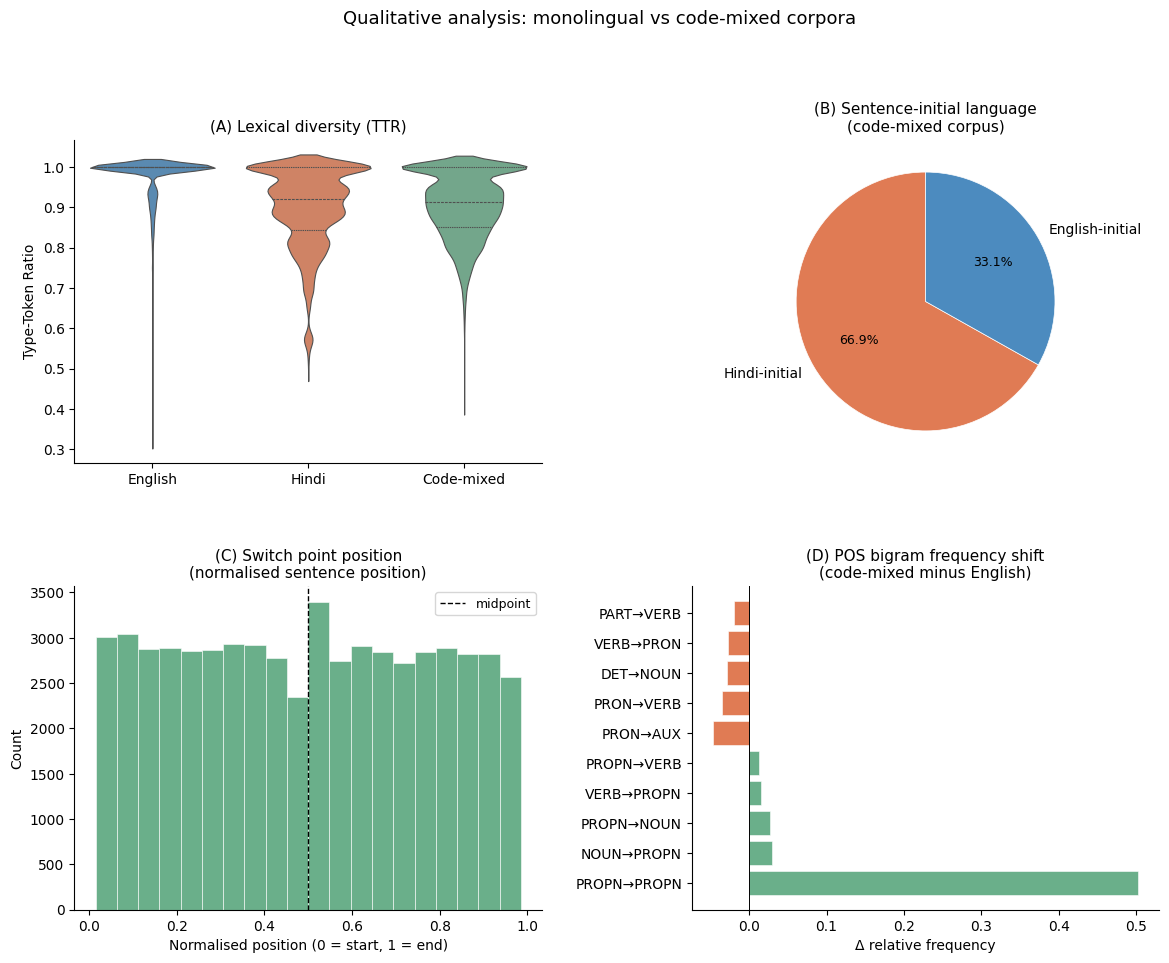

Saved viz_qualitative_4panel.png


In [10]:
# ─── 5. Combined 4-panel qualitative figure ───────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.32)

COLORS = {"English": "#4C8BBF", "Hindi": "#E07B54", "Code-mixed": "#6AAF8A"}

# ── Panel A: TTR violin ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
import seaborn as sns

ttr_data = pd.DataFrame({
    "TTR": ttr_en + ttr_hi + ttr_cm,
    "Corpus": (["English"] * len(ttr_en) +
               ["Hindi"]   * len(ttr_hi) +
               ["Code-mixed"] * len(ttr_cm))
})
order = ["English", "Hindi", "Code-mixed"]
sns.violinplot(data=ttr_data, x="Corpus", y="TTR", order=order,
               palette=COLORS, inner="quartile", linewidth=0.8, ax=ax1)
ax1.set_title("(A) Lexical diversity (TTR)", fontsize=11)
ax1.set_xlabel("")
ax1.set_ylabel("Type-Token Ratio")
ax1.spines[["top", "right"]].set_visible(False)

# ── Panel B: sentence-initial language pie ────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
init_counts = cm_df["initial_lang"].value_counts()
labels_map  = {"HI": "Hindi-initial", "EN": "English-initial", "unknown": "Unknown"}
pie_labels  = [labels_map.get(k, k) for k in init_counts.index]
pie_colors  = ["#E07B54" if "Hindi" in l else
               "#4C8BBF" if "English" in l else "#CCC"
               for l in pie_labels]
wedges, texts, autotexts = ax2.pie(
    init_counts.values,
    labels=pie_labels,
    autopct="%1.1f%%",
    colors=pie_colors,
    startangle=90,
    wedgeprops={"linewidth": 0.5, "edgecolor": "white"}
)
for at in autotexts:
    at.set_fontsize(9)
ax2.set_title("(B) Sentence-initial language\n(code-mixed corpus)", fontsize=11)

# ── Panel C: switch point position histogram ──────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(all_switch_positions, bins=20,
         color="#6AAF8A", edgecolor="white", linewidth=0.4)
ax3.axvline(0.5, color="black", linestyle="--", linewidth=1, label="midpoint")
ax3.set_title("(C) Switch point position\n(normalised sentence position)", fontsize=11)
ax3.set_xlabel("Normalised position (0 = start, 1 = end)")
ax3.set_ylabel("Count")
ax3.legend(fontsize=9)
ax3.spines[["top", "right"]].set_visible(False)

# ── Panel D: POS bigram shift bar chart ───────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])

# pick top-5 enriched and top-5 depleted bigrams
top_enriched = sorted(shifts.items(), key=lambda x: -x[1])[:5]
top_depleted  = sorted(shifts.items(), key=lambda x:  x[1])[:5]
plot_items = top_enriched + top_depleted
plot_labels = [f"{a}→{b}" for (a, b), _ in plot_items]
plot_vals   = [v for _, v in plot_items]
bar_colors  = ["#6AAF8A" if v > 0 else "#E07B54" for v in plot_vals]

bars = ax4.barh(plot_labels, plot_vals, color=bar_colors,
                edgecolor="white", linewidth=0.4)
ax4.axvline(0, color="black", linewidth=0.7)
ax4.set_title("(D) POS bigram frequency shift\n(code-mixed minus English)", fontsize=11)
ax4.set_xlabel("Δ relative frequency")
ax4.spines[["top", "right"]].set_visible(False)

plt.suptitle("Qualitative analysis: monolingual vs code-mixed corpora",
             fontsize=13, y=1.01)
plt.savefig("viz_qualitative_4panel.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved viz_qualitative_4panel.png")

In [ ]:
# ── 3a. CMI formula (Gamback & Das 2014 variant) ─────────────────────────────
def compute_cmi(lang_tags: list) -> float:
    """
    CMI = (N - max_lang_count) / N   if N > 0 else 0
    where N = total tokens (excluding punctuation/unknown),
    max_lang_count = tokens of the most frequent language.
    """
    filtered = [t for t in lang_tags if t not in ("O", "ne", "univ", "acro")]
    N = len(filtered)
    if N == 0:
        return 0.0
    counts = Counter(filtered)
    max_count = max(counts.values())
    return (N - max_count) / N

cm_df["cmi"] = cm_df["lang_tags"].apply(compute_cmi)

# ── 3b. Cross-lingual flux (proportion of adjacent token pairs with diff lang) ─
def compute_flux(lang_tags: list) -> float:
    pairs = [(lang_tags[i], lang_tags[i+1]) for i in range(len(lang_tags)-1)
             if lang_tags[i] not in ("O",) and lang_tags[i+1] not in ("O",)]
    if not pairs:
        return 0.0
    cross = sum(1 for a, b in pairs if a != b)
    return cross / len(pairs)

cm_df["flux"] = cm_df["lang_tags"].apply(compute_flux)

print(cm_df[["text","cmi","flux"]].head(10).to_string(index=False))

                                                                                                                                                                                                                                                       text      cmi     flux
                                                                                                                                    hai behan ki l hai test karna ho ek baar isse boliyega modi ji hai to to mumkin hai fir ye apne asli rang par aa jayegi 0.111111 0.230769
                                                                                                                                                                                                                      apne papa ki pic lagaya ho profile pe 0.375000 0.857143
                                                                                                                                                                                      gill apn

In [ ]:
import spacy
import stanza

# ── 4a. Load parsers ──────────────────────────────────────────────────────────
# English: spaCy (fast, accurate for tweets)
# python -m spacy download en_core_web_sm
nlp_en = spacy.load("en_core_web_sm")

# Hindi: Stanza
stanza.download("hi") # Uncommented this line
nlp_hi = stanza.Pipeline("hi", processors="tokenize,pos,lemma,depparse", verbose=True)

# ── 4b. MDD calculation ───────────────────────────────────────────────────────
def mdd_from_spacy(text: str) -> float | None:
    """Compute Mean Dependency Distance from a spaCy doc."""
    doc = nlp_en(text)
    distances = []
    for token in doc:
        if token.dep_ != "ROOT" and token.head.i != token.i:
            distances.append(abs(token.head.i - token.i))
    return sum(distances) / len(distances) if distances else None

def mdd_from_stanza(text: str) -> float | None:
    """Compute MDD from a Stanza doc (Hindi)."""
    try:
        doc = nlp_hi(text)
        distances = []
        for sent in doc.sentences:
            for word in sent.words:
                if word.head > 0:  # 0 = root
                    distances.append(abs(word.head - word.id))
        return sum(distances) / len(distances) if distances else None
    except Exception:
        return None

# ── 4c. Apply parsers (sample for speed — use full corpus for final report) ───
SAMPLE = 10   # increase to full corpus for final run

eng_sample = eng_df["clean"].dropna().head(SAMPLE)
print("Parsing English...")
eng_df.loc[eng_sample.index, "mdd"] = eng_sample.apply(mdd_from_spacy)

hindi_sample = hindi_df["clean"].dropna().head(SAMPLE)
print("Parsing Hindi...")
hindi_df.loc[hindi_sample.index, "mdd"] = hindi_sample.apply(mdd_from_stanza)

# Code-mixed: use English parser as fallback (or alternate per token language)
print("Parsing code-mixed...")
cm_df["mdd"] = cm_df["clean"].dropna().head(SAMPLE).apply(mdd_from_spacy)

print("\nMDD summary:")
for label, series in [("English", eng_df["mdd"]), ("Hindi", hindi_df["mdd"]),
                       ("Code-mixed", cm_df["mdd"])]:
    s = series.dropna()
    print(f"  {label:12s}: mean={s.mean():.3f}  std={s.std():.3f}  n={len(s)}")

KeyboardInterrupt: 

In [ ]:
!pip install stanza

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 25.8 MB/s eta 0:00:00


In [ ]:
# ─── FAST VERSION: batched Stanza + parallel spaCy ───────────────────────────
import spacy
import stanza
from concurrent.futures import ThreadPoolExecutor
import numpy as np

# ── A. Load parsers (once) ────────────────────────────────────────────────────
nlp_en = spacy.load("en_core_web_sm", disable=["ner", "textcat"])  # drop unused pipes

# Hindi: drop lemma (slow, not needed for MDD), keep only what you need
stanza.download("hi")
nlp_hi = stanza.Pipeline(
    "hi",
    processors="tokenize,pos,lemma,depparse",   # lemma is required by depparse
    tokenize_batch_size=64,
    depparse_batch_size=64,
    verbose=False
)


# ── B. MDD helpers ────────────────────────────────────────────────────────────
def mdd_from_doc(doc) -> float | None:
    """Compute MDD from a spaCy Doc object."""
    distances = [abs(t.head.i - t.i) for t in doc if t.dep_ != "ROOT"]
    return float(np.mean(distances)) if distances else None

def mdd_from_stanza_sent(sent) -> float | None:
    """Compute MDD from a single Stanza sentence."""
    distances = [abs(w.head - w.id) for w in sent.words if w.head > 0]
    return float(np.mean(distances)) if distances else None

# ── C. Batched English parsing (spaCy pipe) ───────────────────────────────────
def parse_english_batch(texts: list[str], batch_size: int = 256) -> list[float | None]:
    """Use spaCy's pipe() — processes a full list, not one-by-one."""
    results = []
    for doc in nlp_en.pipe(texts, batch_size=batch_size):
        results.append(mdd_from_doc(doc))
    return results

# ── D. Batched Hindi parsing (Stanza handles batching internally) ─────────────
def parse_hindi_batch(texts: list[str]) -> list[float | None]:
    """
    Pass the entire list to Stanza at once using a Document list.
    Stanza's batch sizes (set above) handle chunking internally.
    """
    in_docs = [stanza.Document([], text=t) for t in texts]
    out_docs = nlp_hi(in_docs)   # single call — fully batched
    results = []
    for doc in out_docs:
        dists = []
        for sent in doc.sentences:
            dists.extend(abs(w.head - w.id) for w in sent.words if w.head > 0)
        results.append(float(np.mean(dists)) if dists else None)
    return results

# ── E. Run everything ─────────────────────────────────────────────────────────
SAMPLE = None   # set to None to use full corpus

def get_sample(series, n):
    return series.dropna().head(n).tolist() if n else series.dropna().tolist()

eng_texts  = get_sample(eng_df["clean"],   SAMPLE)
hindi_texts = get_sample(hindi_df["clean"], SAMPLE)
cm_texts   = get_sample(cm_df["clean"],    SAMPLE)

print("Parsing English (batched)...")
eng_mdds = parse_english_batch(eng_texts)

print("Parsing Hindi (batched Stanza)...")
hindi_mdds = parse_hindi_batch(hindi_texts)

print("Parsing code-mixed (batched)...")
cm_mdds = parse_english_batch(cm_texts)

# Write back to dataframes
eng_df.loc[eng_df["clean"].dropna().head(SAMPLE).index,   "mdd"] = eng_mdds
hindi_df.loc[hindi_df["clean"].dropna().head(SAMPLE).index, "mdd"] = hindi_mdds
cm_df.loc[cm_df["clean"].dropna().head(SAMPLE).index,     "mdd"] = cm_mdds

# ── F. Summary ────────────────────────────────────────────────────────────────
print("\nMDD summary:")
for label, series in [("English", eng_df["mdd"]), ("Hindi", hindi_df["mdd"]),
                       ("Code-mixed", cm_df["mdd"])]:
    s = series.dropna()
    print(f"  {label:12s}: mean={s.mean():.3f}  std={s.std():.3f}  n={len(s)}")

Parsing English (batched)...
Parsing Hindi (batched Stanza)...
Parsing code-mixed (batched)...

MDD summary:
  English     : mean=2.158  std=0.759  n=5016
  Hindi       : mean=3.623  std=1.099  n=6051
  Code-mixed  : mean=3.028  std=0.825  n=6420


/tmp/ipykernel_2671/1422543685.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=mdd_combined, x="corpus", y="mdd", order=order,
/tmp/ipykernel_2671/1422543685.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=mdd_combined, x="corpus", y="mdd", order=order,


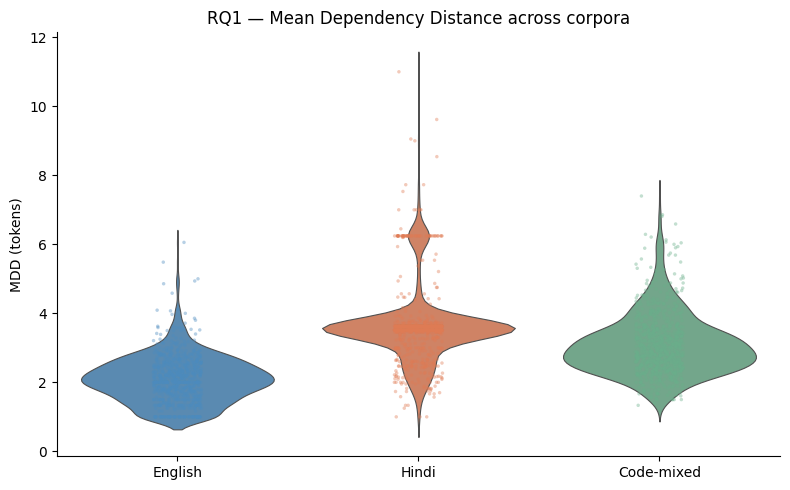

In [ ]:
# ── 5a. Build combined frame ──────────────────────────────────────────────────
mdd_combined = pd.concat([
    eng_df[["mdd"]].assign(corpus="English"),
    hindi_df[["mdd"]].assign(corpus="Hindi"),
    cm_df[["mdd"]].assign(corpus="Code-mixed"),
]).dropna()

# ── 5b. Violin + strip plot ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
order = ["English", "Hindi", "Code-mixed"]
colors = ["#4C8BBF", "#E07B54", "#6AAF8A"]

sns.violinplot(data=mdd_combined, x="corpus", y="mdd", order=order,
               palette=dict(zip(order, colors)), inner=None, linewidth=0.8, ax=ax)
sns.stripplot(data=mdd_combined, x="corpus", y="mdd", order=order,
              palette=dict(zip(order, colors)), size=2.5, alpha=0.4, jitter=True, ax=ax)

ax.set_title("RQ1 — Mean Dependency Distance across corpora", fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("MDD (tokens)")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("viz2_mdd_violin.png", dpi=150, bbox_inches="tight")
plt.show()

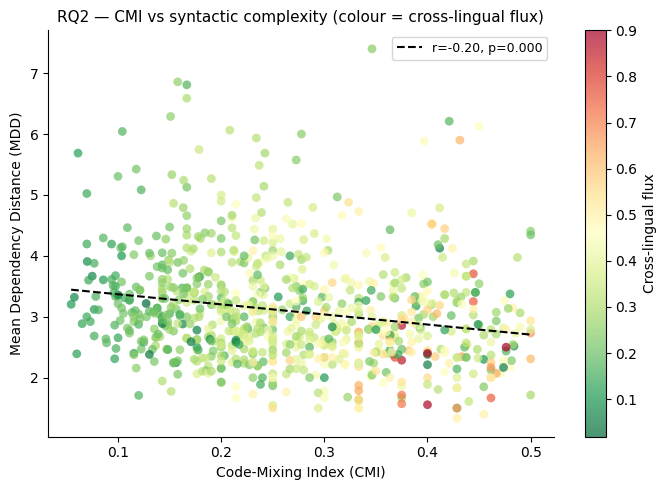


Pearson r = -0.205, p = 0.0000, slope = -1.657


In [ ]:
# ── 6a. CMI scatter ───────────────────────────────────────────────────────────
from scipy import stats

cm_plot = cm_df.dropna(subset=["mdd", "cmi"])

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(cm_plot["cmi"], cm_plot["mdd"],
                c=cm_plot["flux"], cmap="RdYlGn_r",
                s=40, alpha=0.7, edgecolors="none")
plt.colorbar(sc, ax=ax, label="Cross-lingual flux")

# Regression line
slope, intercept, r, p, se = stats.linregress(cm_plot["cmi"], cm_plot["mdd"])
xs = pd.Series([cm_plot["cmi"].min(), cm_plot["cmi"].max()])
ax.plot(xs, slope * xs + intercept, color="black", linewidth=1.5, linestyle="--",
        label=f"r={r:.2f}, p={p:.3f}")

ax.set_xlabel("Code-Mixing Index (CMI)")
ax.set_ylabel("Mean Dependency Distance (MDD)")
ax.set_title("RQ2 — CMI vs syntactic complexity (colour = cross-lingual flux)", fontsize=11)
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("viz3_cmi_mdd_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nPearson r = {r:.3f}, p = {p:.4f}, slope = {slope:.3f}")

In [ ]:
from scipy.stats import f_oneway, ttest_ind

en_mdd = eng_df["mdd"].dropna().astype(float).values
hi_mdd = hindi_df["mdd"].dropna().astype(float).values
cm_mdd = cm_df["mdd"].dropna().astype(float).values

# ── 7a. One-way ANOVA ────────────────────────────────────────────────────────
F, p_anova = f_oneway(en_mdd, hi_mdd, cm_mdd)
print(f"One-way ANOVA: F={F:.3f}, p={p_anova:.4f}")

# ── 7b. Pairwise Welch's t-tests ─────────────────────────────────────────────
pairs = [("English", en_mdd, "Hindi", hi_mdd),
         ("English", en_mdd, "Code-mixed", cm_mdd),
         ("Hindi",   hi_mdd, "Code-mixed", cm_mdd)]
print("\nPairwise Welch's t-tests (equal_var=False):")
for n1, g1, n2, g2 in pairs:
    t, p = ttest_ind(g1, g2, equal_var=False)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {n1} vs {n2:12s}: t={t:7.3f}, p={p:.4f}  {sig}")

# ── 7c. Effect size (Cohen's d) ───────────────────────────────────────────────
import numpy as np

def cohens_d(a, b):
    pooled_std = np.sqrt((np.std(a,ddof=1)**2 + np.std(b,ddof=1)**2) / 2)
    return (np.mean(a) - np.mean(b)) / pooled_std if pooled_std > 0 else 0

print("\nCohen's d effect sizes:")
for n1, g1, n2, g2 in pairs:
    d = cohens_d(g1, g2)
    print(f"  {n1} vs {n2:12s}: d={d:.3f}")

One-way ANOVA: F=566.506, p=0.0000

Pairwise Welch's t-tests (equal_var=False):
  English vs Hindi       : t=-32.860, p=0.0000  ***
  English vs Code-mixed  : t=-25.009, p=0.0000  ***
  Hindi vs Code-mixed  : t= 10.538, p=0.0000  ***

Cohen's d effect sizes:
  English vs Hindi       : d=-1.648
  English vs Code-mixed  : d=-1.256
  Hindi vs Code-mixed  : d=0.527


Explained variance ratio: [0.498 0.248 0.139 0.098 0.016]
Cumulative explained variance: [0.498 0.747 0.886 0.984 1.   ]


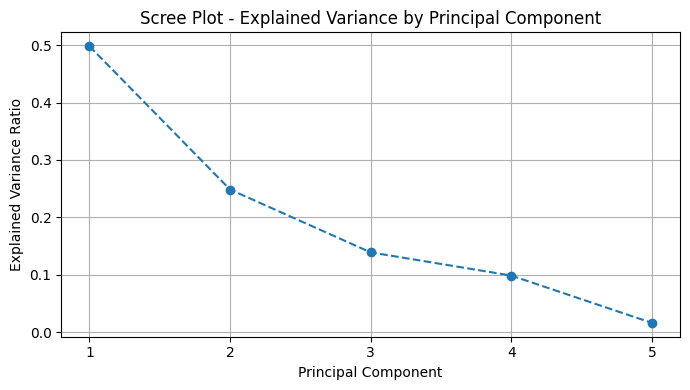


PCA Component Loadings:
                 PC1    PC2
mdd           -0.538  0.394
cmi            0.330  0.578
flux           0.329  0.622
sent_len      -0.429 -0.030
branch_factor  0.556 -0.352


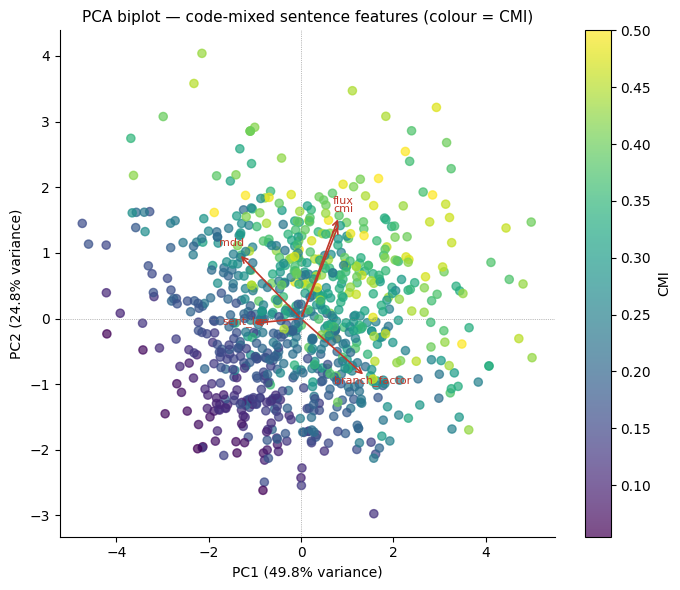

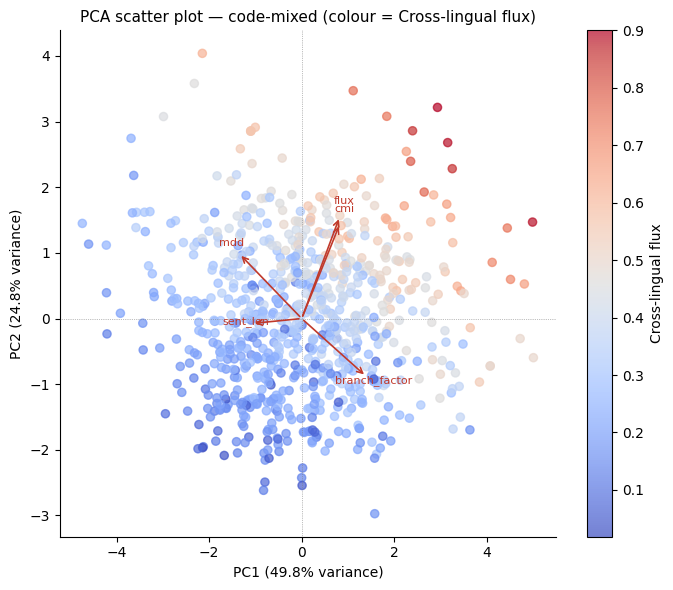

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ── 8a. Build sentence-level feature matrix from code-mixed data ───────────────
cm_features = cm_df.dropna(subset=["mdd","cmi","flux"]).copy()
cm_features["sent_len"] = cm_features["tokens"].apply(len)

# Branching factor: avg number of tokens per unique head position
# (proxy here: 1 / avg dependency distance as branching spread)
cm_features["branch_factor"] = 1 / (cm_features["mdd"] + 1e-6)

feat_cols = ["mdd", "cmi", "flux", "sent_len", "branch_factor"]
X = cm_features[feat_cols].values
X_scaled = StandardScaler().fit_transform(X)

# ── 8b. Fit PCA ───────────────────────────────────────────────────────────────
pca = PCA(n_components=5) # Fit with more components to make scree plot
coords = pca.fit_transform(X_scaled)
cm_features["PC1"] = coords[:, 0]
cm_features["PC2"] = coords[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))
print("Cumulative explained variance:", pca.explained_variance_ratio_.cumsum().round(3))

# ── 8c. Scree Plot (new visualization) ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_, marker='o', linestyle='--')
plt.title('Scree Plot - Explained Variance by Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.tight_layout()
plt.savefig("viz4_scree_plot.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 8d. PCA Component Loadings (new insight) ──────────────────────────────────
print("\nPCA Component Loadings:")
loadings_df = pd.DataFrame(pca.components_[:2].T, columns=['PC1', 'PC2'], index=feat_cols)
print(loadings_df.round(3))

# ── 8e. Biplot (original, for CMI) ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(cm_features["PC1"], cm_features["PC2"],
                c=cm_features["cmi"], cmap="viridis", s=35, alpha=0.7)
plt.colorbar(sc, ax=ax, label="CMI")

# Loading arrows
scale = 2.5 # Adjust scale as needed for better visualization
for i, feat in enumerate(feat_cols):
    ax.annotate("", xy=(pca.components_[0,i]*scale, pca.components_[1,i]*scale),
                xytext=(0,0),
                arrowprops=dict(arrowstyle="->", color="#C0392B", lw=1.2))
    ax.text(pca.components_[0,i]*scale*1.12, pca.components_[1,i]*scale*1.12,
            feat, fontsize=8, color="#C0392B", ha="center")

ev = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% variance)")
ax.set_title("PCA biplot — code-mixed sentence features (colour = CMI)", fontsize=11)
ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")
ax.axvline(0, color="gray", linewidth=0.5, linestyle=":")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("viz4_pca_biplot_cmi.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 8f. PCA scatter plot colored by Cross-lingual flux (new visualization) ────
fig, ax = plt.subplots(figsize=(7, 6))
sc_flux = ax.scatter(cm_features["PC1"], cm_features["PC2"],
                     c=cm_features["flux"], cmap="coolwarm", s=35, alpha=0.7)
plt.colorbar(sc_flux, ax=ax, label="Cross-lingual flux")

# Loading arrows (re-using for consistency, though flux coloring might emphasize different aspects)
for i, feat in enumerate(feat_cols):
    ax.annotate("", xy=(pca.components_[0,i]*scale, pca.components_[1,i]*scale),
                xytext=(0,0),
                arrowprops=dict(arrowstyle="->", color="#C0392B", lw=1.2))
    ax.text(pca.components_[0,i]*scale*1.12, pca.components_[1,i]*scale*1.12,
            feat, fontsize=8, color="#C0392B", ha="center")

ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% variance)")
ax.set_title("PCA scatter plot — code-mixed (colour = Cross-lingual flux)", fontsize=11)
ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")
ax.axvline(0, color="gray", linewidth=0.5, linestyle=":")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("viz5_pca_biplot_flux.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── 10a. Consolidated results CSV ─────────────────────────────────────────────
report_df = pd.concat([
    eng_df[["text","corpus","mdd"]],
    hindi_df[["text","corpus","mdd"]],
    cm_df[["text","corpus","mdd","cmi","flux"]],
], ignore_index=True)
report_df.to_csv("results_all_corpora.csv", index=False)

# ── 10b. Stats summary table ──────────────────────────────────────────────────
summary = report_df.groupby("corpus")["mdd"].agg(
    n="count", mean="mean", std="std", median="median",
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75)
).round(3)
print("\n=== FINAL SUMMARY TABLE ===")
print(summary.to_string())
summary.to_csv("summary_table.csv")

print("\nAll visualisations and results saved.")


=== FINAL SUMMARY TABLE ===
             n      mean    std    median    q25    q75
corpus                                                 
codemixed  200  3.176912  0.955       3.0  2.529  3.485
english    194  2.075047  0.684       2.0  1.635  2.455
hindi      200  3.675469  1.213  3.516667  3.261  3.517

All visualisations and results saved.
